## Grain Structure Smoothing Workflow

This notebook builds a 2D Monte‑Carlo grain structure, characterizes grains, converts pixelized regions to polygons, and applies boundary smoothing before visualization.

### Objectives
- Simulate a 2D grain structure and detect grains.
- Characterize grain morphology and neighbor relationships.
- Polygonize grain boundaries for geometric operations.
- Smooth grain boundary segments and visualize results.

### Key Variables
- `pxt`: Monte‑Carlo grain structure object (`mcgs`).
- `gstslice`: temporal slice holding grain data and properties.
- `geom`: polygonized grain structure for geometry operations.
- `npasses`: number of smoothing passes.
- `min_segment_length_factor`: smoothing scale per pass.
- `gsname`: label for the smoothed geometry.
- `smoothed_grains`: smoothed polygon dictionary.

### Controlling Smoothing
- Increase `npasses` for stronger smoothing.
- Increase `min_segment_length_factor` to enforce longer segment filtering per pass.
- Update `gsname` to track parameter sets.
- Re-run `geom.smooth_gbsegs(...)` with new parameters to regenerate smoothed polygons.

### Import modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from upxo.ggrowth.mcgs import mcgs
import pyvista as pv
from copy import deepcopy
from upxo.pxtal.geometrification import polygonised_grain_structure

### Simulate GS and detect grains

In [2]:
pxt = mcgs(input_dashboard = 'C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\confMesh\\confMesh1.xls')
pxt.simulate()
pxt.detect_grains(library='cc3d', connectivity=4)

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\confMesh\confMesh1.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 50.0, 1.0
     ymin, ymax, yinc: 0.0, 50.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 20
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
|--------------- MC SIM RUN COMPLETED on: ALG200---------------|
Using cc3d for grain identification


### Sleect a GS temporal slcie

In [3]:
tslice = list(pxt.gs.keys())[-1]
gstslice = pxt.gs[tslice]

### Characterize gstslice

In [4]:
gstslice.char_morph_2d(bbox=True, use_version=2, bbox_ex=True, npixels=False,
                npixels_gb=False, area=True, eq_diameter=True,
                perimeter=True, perimeter_crofton=True,
                compactness=True, gb_length_px=False,
                aspect_ratio=True,
                solidity=True, morph_ori=False,
                circularity=False,
                eccentricity=False, feret_diameter=True,
                major_axis_length=False, minor_axis_length=False,
                euler_number=False, append=False, saa=True,
                throw=False, char_grain_positions=False,
                find_neigh=False, char_gb=True,
                make_skim_prop=True, get_grain_coords=False)
gstslice.find_neigh()

Characterising MC simulation time-slice 9
10.6%, 21.2%, 31.8%, 42.4%, 52.9%, 63.5%, 74.1%, 84.7%, 95.3%, 100.0%Need area, aspect_ratio, major_axis_length, minor_axis_length to correct aspect ratio. Skipping aspect ratio correction.

Extracting neigh list for all grains



### Initiate the polygonization procedure
This initiates all naecessary steps needed to generate a geometric varient of the pixellated grain structurea

In [5]:
geom = polygonised_grain_structure(gstslice.lgi, gstslice.gid, gstslice.neigh_gid)

### Convert pixellated grain structure to geometric grain structure
This is a very detailed procedure. As of the time I wroite here, there exists a non-zero failure rate. Failures are triggered by special geometries of grains such as presence of island grains, etc. Failure rate is:
* high for MCALG 202 and low for MCALG 200. 
* high at higher simulation temperatures
* Low values of MC STATE, Q
* Low temporal location of the grain structure slice.

For MCALG 200, most widely used algorithm, for no consideration paid to transition probabiltity, at sufficiently hig htemporal location and Q > 5, failure rates are 5 to 10 %. This issue will be adressed in one of the future releases. - Dr. Sunil Anandatheertha

In [6]:
geom.pix_to_geom(verbose=False)

c:\Users\rg5749\AppData\Local\anaconda3\envs\UPXO313a\Lib\site-packages\rasterio\io.py:143: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  rd = writer(


Extracting Junction points 58.82 % complete.


### Visualize the geometric pixel type grain structure
This is the first geometrification result. It still retains the pixelated appearance. We will see this now.

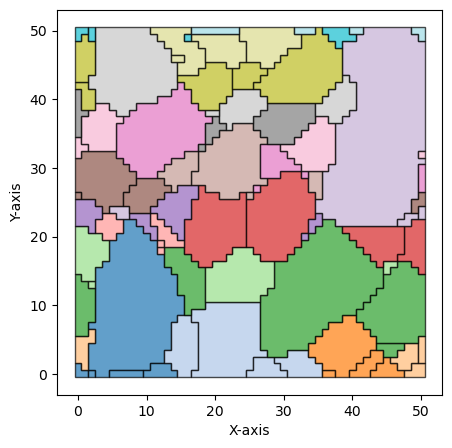

In [7]:
fig, ax = geom.plotgs(geom.POLYXTAL, figsize=(5,5), dpi=100)
# ax.set_axis_off()

### Set smoothing control parameters
* `npasses`. The number of passes to be used in smoothing a given grain boundary segment.
* `min_segment_length_factor`. The threshold length factor for a grain boundary segment to enable smoothing over it. A grain boundary segment with lesser length will not be smoothed.

In [8]:
npasses = 2
min_segment_length_factor = 2

Set a name for the smoothed grain strucutre

In [9]:
gsname = 'gs.'+str(npasses)+'passes.'+ str(min_segment_length_factor) + 'minseglenfactor'

### Smooth the grain structure

In [10]:
geom.smooth_gbsegs(geom.GB, npasses=npasses,
                   max_smooth_levels=np.repeat(min_segment_length_factor, npasses),
                   plot=False, name=gsname)
geom.smoothed.keys()

Assembling grain boundary segments into grain boundary multi-linestrings
Carrying out smoothing pass: 1
Carrying out smoothing pass: 2


dict_keys(['gs.2passes.2minseglenfactor'])

### See the smoothed grain structure

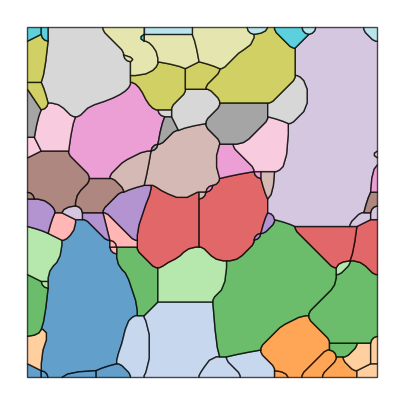

In [11]:
fig, ax = geom.plotgs(geom.smoothed[gsname]['POLYXTAL'], cmap='tab20', 
                      figsize=(5,5), dpi=100)
ax.set_axis_off()